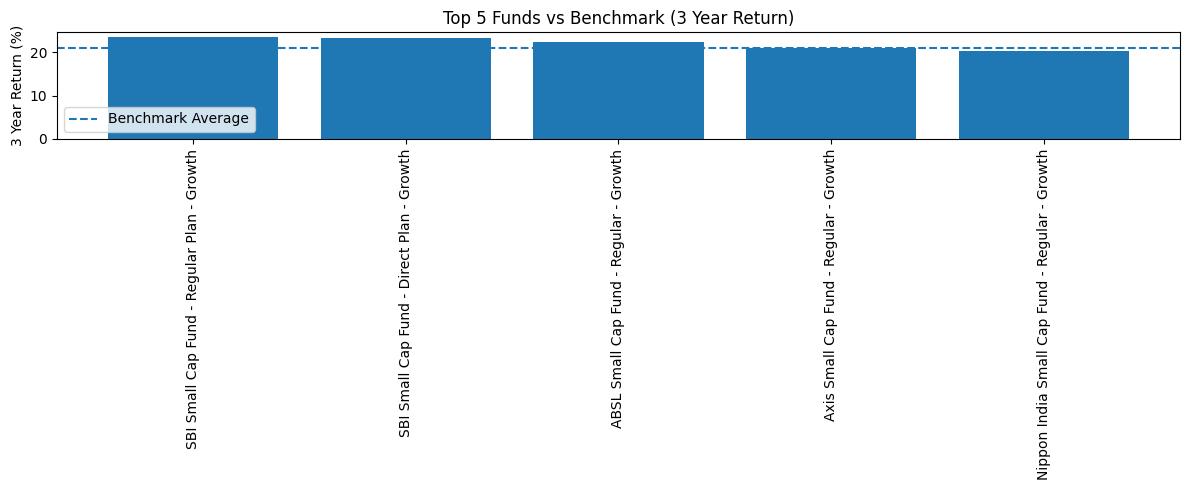

In [17]:
import matplotlib.pyplot as plt

top5 = perf.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(12,5))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"]
)

plt.axhline(
    y=top5["benchmark_3yr_pct"].mean(),
    linestyle="--",
    label="Benchmark Average"
)

plt.title("Top 5 Funds vs Benchmark (3 Year Return)")
plt.ylabel("3 Year Return (%)")

plt.xticks(rotation=90)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/Benchmark_Comparison.png",
    bbox_inches="tight"
)

plt.show()

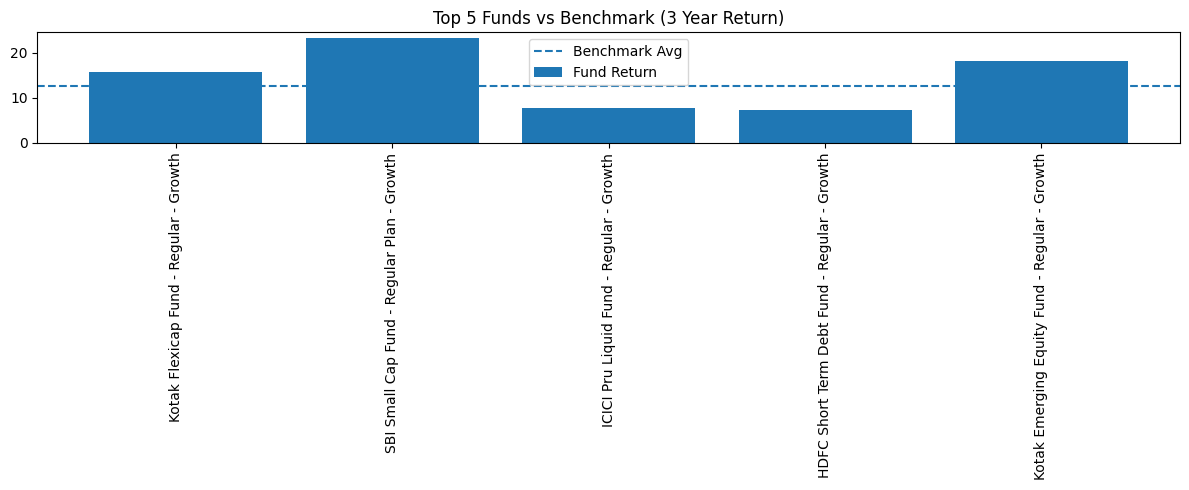

In [16]:
top5 = scorecard.head(5)

plt.figure(figsize=(12,5))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"],
    label="Fund Return"
)

plt.axhline(
    y=top5["benchmark_3yr_pct"].mean(),
    linestyle="--",
    label="Benchmark Avg"
)

plt.title(
    "Top 5 Funds vs Benchmark (3 Year Return)"
)

plt.xticks(rotation=90)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/Benchmark_Comparison.png"
)

plt.show()

In [15]:
alpha_beta = perf[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


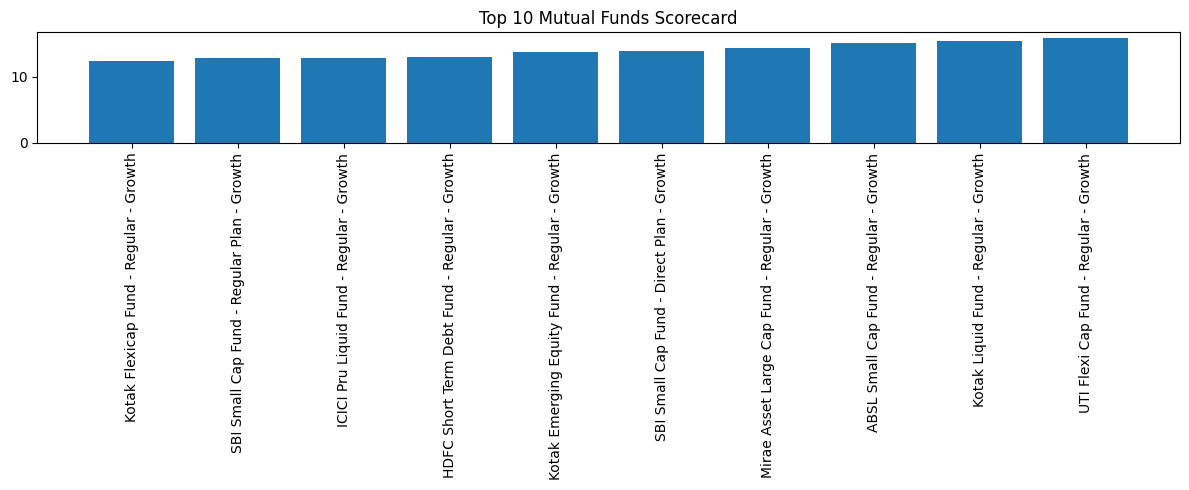

In [14]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top10["scheme_name"],
    top10["fund_score"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Mutual Funds Scorecard")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/Top_10_Fund_Scorecard.png"
)

plt.show()

In [13]:
scorecard = perf.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=False
)

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=True
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,20.0,12.300
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,8.0,12.750
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,39116,0.74,5,Low,35.0,1.0,3.5,7.0,3.0,12.800
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,27953,0.56,3,Low,36.0,4.0,1.0,2.0,6.0,12.900
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,25.0,13.700
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,30.0,13.800
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,17.0,7.5,12.0,23.0,15.0,14.325
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,27.0,15.000
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,27623,0.60,3,Low,37.0,2.0,14.0,3.0,5.0,15.350
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,...,17912,1.64,5,Moderately High,13.0,15.0,8.0,39.5,7.0,15.875


In [12]:
fund = pd.read_sql(
    "SELECT * FROM dim_fund",
    conn
)

print(fund.head())
print(fund.columns.tolist())

Empty DataFrame
Columns: [fund_id, fund_name]
Index: []
['fund_id', 'fund_name']


In [11]:
perf = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)

print(perf.head())
print(perf.columns.tolist())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [10]:
conn.close()

conn = sqlite3.connect("../bluestock_mf.db")

cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())

[('dim_fund',), ('dim_date',), ('fact_nav',), ('fact_transactions',), ('fact_performance',)]


In [9]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".db"):
            print(os.path.join(root, file))

..\bluestock_mf.db
..\mutual_fund.db


In [8]:
import os
print(os.getcwd())

c:\Users\varun\OneDrive\Desktop\Mutal_Fund-Capstone\notebooks


In [7]:
print(conn)

In [6]:
cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())


[]


In [5]:
scheme_perf = pd.read_sql(
    "SELECT * FROM scheme_performance",
    conn
)

benchmark = pd.read_sql(
    "SELECT * FROM benchmark_indices",
    conn
)

print(scheme_perf.head())
print(benchmark.head())

DatabaseError: Execution failed on sql 'SELECT * FROM scheme_performance': no such table: scheme_performance

In [2]:
conn = sqlite3.connect("../mutual_fund.db")

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt